# Retail Intelligence - EDA, Charts & Executive Summary
**Project 1 | Day 4 | 20-Day Data Analytics, Data Science & Gen AI Bootcamp**

This notebook loads the SQL query outputs produced on Day 2 (aggregations/KPIs) and
Day 3 (RFM, cohort retention, product pairs, revenue growth), runs a basic EDA pass,
builds the required charts, answers the three Day-4 business questions, and exports
`summary_metrics.csv` for the follow-on Power BI mini-project.

**Business questions to answer:**
1. Which category and region gives the highest revenue?
2. How many customers are at risk of leaving?
3. Did promotions help increase sales?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import textwrap
from pathlib import Path
from matplotlib.backends.backend_pdf import PdfPages

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titlepad"] = 12

DAY2_DIR = Path("../Day-2/Query_Results")
DAY3_DIR = Path("../Day-3/Query_Results_Day3")

## 1. Load Data
Load every CSV export from Day 2 and Day 3 into a dictionary of DataFrames.

In [ ]:
csv_files = sorted(DAY2_DIR.glob("*.csv")) + sorted(DAY3_DIR.glob("*.csv"))

all_data = {}
for f in csv_files:
    key = f.stem.strip()
    all_data[key] = pd.read_csv(f)

print(f"Loaded {len(all_data)} CSV files from Day 2 and Day 3:\n")
for name, df in all_data.items():
    print(f" - {name:<28} {df.shape[0]:>7,} rows x {df.shape[1]} cols")

Loaded 16 CSV files from Day 2 and Day 3:

 - Query_1                            9 rows x 3 cols
 - Query_10                          21 rows x 4 cols
 - Query_2                            5 rows x 2 cols
 - Query_3                        1,000 rows x 3 cols
 - Query_4                            2 rows x 5 cols
 - Query_5                          158 rows x 2 cols
 - Query_6                        5,555 rows x 5 cols
 - Query_7                           50 rows x 5 cols
 - Query_8                            1 rows x 13 cols
 - Query_9                            1 rows x 3 cols
 - 1.RFM_scores                   5,001 rows x 9 cols
 - 1b.RFM_scores_summary              5 rows x 8 cols
 - 2.cohort _retention            1,711 rows x 5 cols
 - 3.product_pairs                   20 rows x 5 cols
 - 4.revenue_growth                   5 rows x 5 cols
 - 5.total_revenue_by_month          58 rows x 3 cols


In [ ]:
# Friendly references to the tables used most often below
revenue_by_city_type = all_data["Query_1"]     # city, store_type, total_revenue
category_revenue     = all_data["Query_2"]     # category, total_revenue (top 5)
top_spenders         = all_data["Query_3"]     # customer_id, total_spend, spend_tier
promo_comparison     = all_data["Query_4"]     # promotion_status, sales, revenue, AOV
above_avg_spenders   = all_data["Query_5"]     # customer_id, total_spend
store_rank           = all_data["Query_7"]     # store_id, store_name, city, revenue, rank
data_quality_check   = all_data["Query_8"]     # null / negative value counts
repeat_purchase_rate = all_data["Query_9"]     # repeat_customers, total_customers, rate
city_category_mix    = all_data["Query_10"]    # city, category, revenue, mix %

rfm_scores       = all_data["1.RFM_scores"]          # per-customer RFM scores + segment
rfm_summary      = all_data["1b.RFM_scores_summary"] # per-segment rollup
cohort_retention = all_data["2.cohort _retention"]   # cohort_month x month_number retention
product_pairs    = all_data["3.product_pairs"]       # top co-purchased product pairs
revenue_growth   = all_data["4.revenue_growth"]      # sales_year, YoY growth
monthly_revenue  = all_data["5.total_revenue_by_month"]  # sales_month, revenue, running total

## 2. Exploratory Data Analysis
For every table: data types, missing values, and duplicate rows.

In [ ]:
for name, df in all_data.items():
    print("=" * 72)
    print(name, f"({df.shape[0]} rows x {df.shape[1]} cols)")
    print("-" * 72)
    print(df.dtypes.to_string())
    missing = df.isna().sum()
    missing = missing[missing > 0]
    print(f"\nMissing values:\n{missing.to_string() if not missing.empty else '  None'}")
    print(f"\nDuplicate rows: {df.duplicated().sum()}")
    print()

Query_1 (9 rows x 3 cols)
------------------------------------------------------------------------
city                 str
store_type           str
total_revenue    float64

Missing values:
  None

Duplicate rows: 0

Query_10 (21 rows x 4 cols)
------------------------------------------------------------------------
city                    str
category                str
category_revenue    float64
category_mix_pct    float64

Missing values:
  None

Duplicate rows: 0

Query_2 (5 rows x 2 cols)
------------------------------------------------------------------------
category             str
total_revenue    float64

Missing values:
  None

Duplicate rows: 0

Query_3 (1000 rows x 3 cols)
------------------------------------------------------------------------
customer_id    float64
total_spend    float64
spend_tier         str

Missing values:
customer_id    1

Duplicate rows: 0

Query_4 (2 rows x 5 cols)
------------------------------------------------------------------------
promotio

### Summary statistics for the key numeric tables

In [ ]:
monthly_revenue.describe()

,monthly_revenue,running_total_revenue
count,5.800000e+01,5.800000e+01
mean,1.262326e+06,3.795575e+07
std,4.172475e+05,2.109378e+07
min,7.227271e+05,1.980352e+06
25%,8.311075e+05,2.009539e+07
50%,1.188575e+06,3.797061e+07
75%,1.574483e+06,5.638133e+07
max,2.189798e+06,7.321493e+07


In [ ]:
rfm_scores.describe()

,customer_id,recency_days,frequency,monetary,r_score,f_score,m_score,rfm_code
count,5000.000000,5001.000000,5001.000000,5.001000e+03,5001.000000,5001.000000,5001.000000,5001.000000
mean,2500.500000,23.392521,93.886223,1.464006e+04,2.999600,2.999600,2.999600,332.955609
std,1443.520003,23.454272,25.421700,2.591649e+05,1.414496,1.414496,1.414496,143.543230
min,1.000000,0.000000,62.000000,5.902600e+03,1.000000,1.000000,1.000000,111.000000
25%,1250.750000,6.000000,87.000000,9.679590e+03,2.000000,2.000000,2.000000,221.000000
50%,2500.500000,17.000000,93.000000,1.088866e+04,3.000000,3.000000,3.000000,334.000000
75%,3750.250000,33.000000,100.000000,1.219220e+04,4.000000,4.000000,4.000000,445.000000
max,5000.000000,170.000000,1765.000000,1.833806e+07,5.000000,5.000000,5.000000,555.000000


### Data quality note

`Query_3`, `Query_5`, and `1.RFM_scores` each contain **one row with a blank
`customer_id`** carrying an unusually large `total_spend` / `monetary` value. This
is not a real customer — it's the aggregation bucket for orders where
`customer_id` wasn't captured (e.g. guest checkout / a data-entry gap upstream).
`Query_8`'s data-quality check reports 0 null `customer_id`s at the *raw order*
level, so this gap is specific to how these three queries grouped the data.

We flag it here and exclude it from any customer-level ranking below.

In [ ]:
# Remove the null-customer_id aggregate row before doing customer-level analysis
top_spenders_clean = top_spenders.dropna(subset=["customer_id"]).copy()
rfm_scores_clean = rfm_scores.dropna(subset=["customer_id"]).copy()

print(f"top_spenders:  removed {len(top_spenders) - len(top_spenders_clean)} null-customer_id row(s)")
print(f"rfm_scores:    removed {len(rfm_scores) - len(rfm_scores_clean)} null-customer_id row(s)")

top_spenders:  removed 1 null-customer_id row(s)


rfm_scores:    removed 1 null-customer_id row(s)


## 3. Charts

### Chart 1 — Line chart: Monthly revenue trend

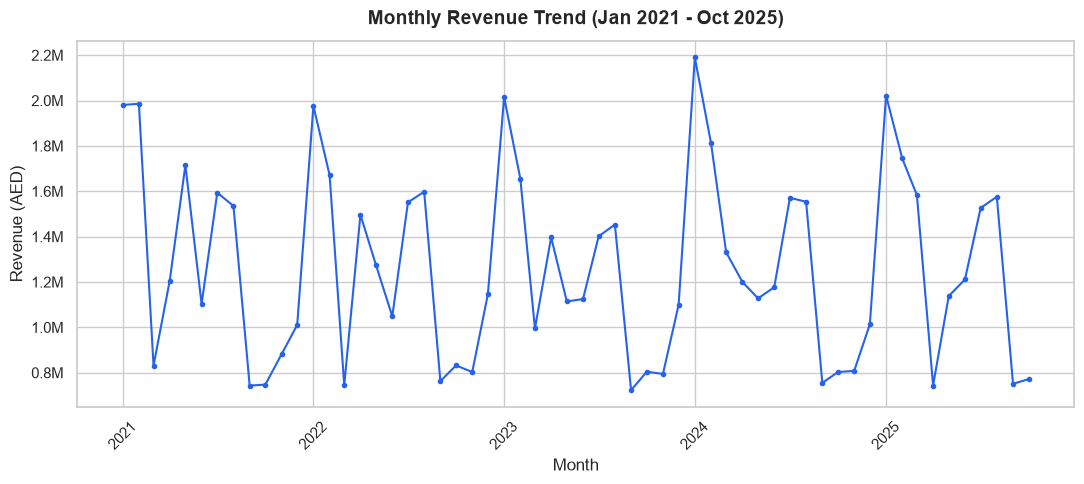

In [ ]:
monthly_revenue = monthly_revenue.copy()
monthly_revenue["sales_month"] = pd.to_datetime(monthly_revenue["sales_month"])

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(monthly_revenue["sales_month"], monthly_revenue["monthly_revenue"],
        marker="o", markersize=3, linewidth=1.5, color="#2563eb")
ax.set_title("Monthly Revenue Trend (Jan 2021 - Oct 2025)", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (AED)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("chart1_monthly_revenue_trend.png", dpi=150)
plt.show()

### Chart 2 — Bar chart: Revenue by region

The Day 2/3 exports don't carry a separate `region` field — `city` (Dubai, Abu
Dhabi, Sharjah) is the geographic grain available, so it's used as the region axis.

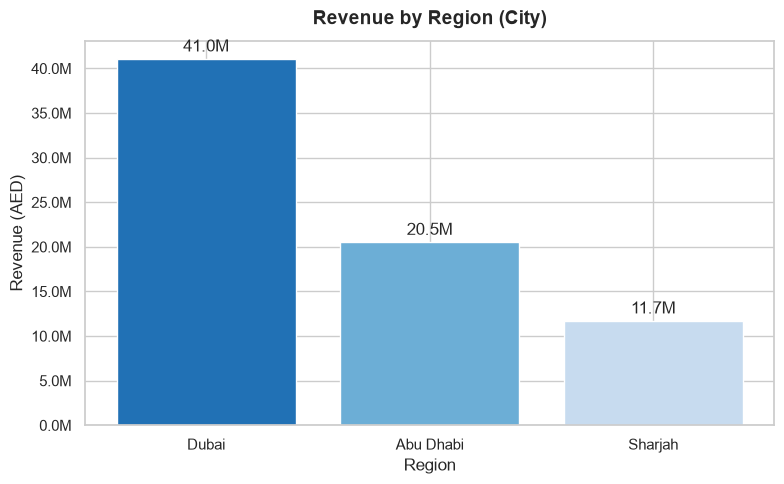

In [ ]:
revenue_by_city = revenue_by_city_type.groupby("city")["total_revenue"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(revenue_by_city.index, revenue_by_city.values,
               color=sns.color_palette("Blues_r", len(revenue_by_city)))
ax.set_title("Revenue by Region (City)", fontsize=14, fontweight="bold")
ax.set_xlabel("Region")
ax.set_ylabel("Revenue (AED)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax.bar_label(bars, labels=[f"{v/1e6:.1f}M" for v in revenue_by_city.values], padding=3)
plt.tight_layout()
plt.savefig("chart2_revenue_by_region.png", dpi=150)
plt.show()

### Chart 3 — Bar chart: Top 10 products

**Data-availability note:** none of the Day 2 / Day 3 SQL exports contain
per-product revenue (`Query_6`, "products with falling sales month over month",
came back with 0 rows, and no other query aggregates revenue at the product
level). The only product-level signal available is Day 3's `product_pairs.csv`
(top co-purchased pairs), so this chart ranks products by how often they show up
in a top co-purchase pair — a **popularity proxy, not a revenue ranking**. To get
a true "top 10 products by revenue" chart, re-run a `GROUP BY sku_id` revenue
query against the source database and drop the export into this folder.

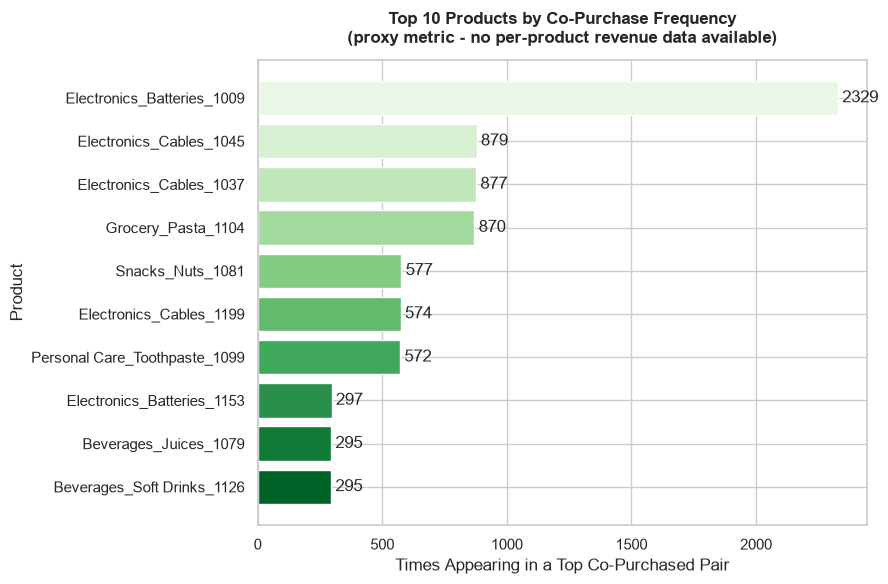

In [ ]:
pairs_long = pd.concat([
    product_pairs[["product_1", "times_bought_together"]].rename(columns={"product_1": "product"}),
    product_pairs[["product_2", "times_bought_together"]].rename(columns={"product_2": "product"}),
])
top_products = (pairs_long.groupby("product")["times_bought_together"]
                .sum().sort_values(ascending=False).head(10))

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(top_products.index[::-1], top_products.values[::-1],
                color=sns.color_palette("Greens_r", len(top_products)))
ax.set_title("Top 10 Products by Co-Purchase Frequency\n(proxy metric - no per-product revenue data available)",
              fontsize=12.5, fontweight="bold")
ax.set_xlabel("Times Appearing in a Top Co-Purchased Pair")
ax.set_ylabel("Product")
ax.bar_label(bars, padding=3)
plt.tight_layout()
plt.savefig("chart3_top10_products.png", dpi=150)
plt.show()

### Chart 4 — Pie chart: RFM customer segments

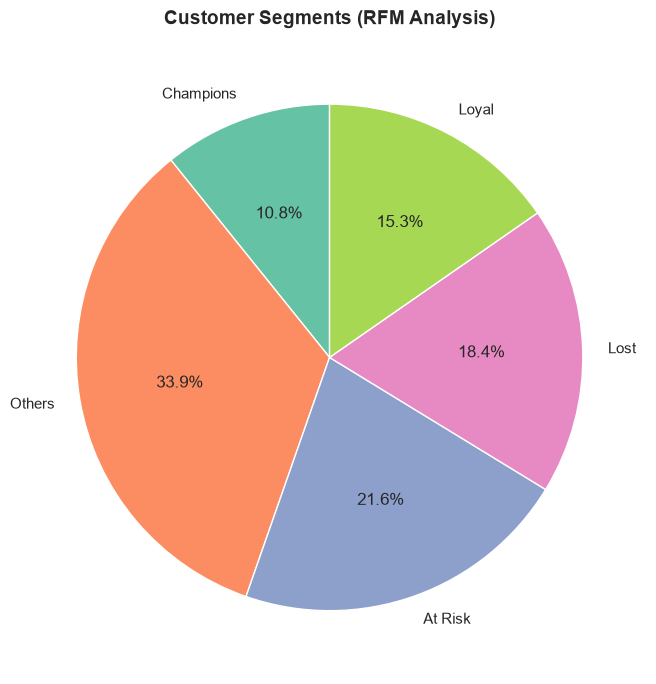

In [ ]:
fig, ax = plt.subplots(figsize=(7, 7))
colors = sns.color_palette("Set2", len(rfm_summary))
ax.pie(rfm_summary["customer_count"], labels=rfm_summary["customer_segment"],
       autopct="%1.1f%%", startangle=90, colors=colors,
       wedgeprops={"edgecolor": "white", "linewidth": 1})
ax.set_title("Customer Segments (RFM Analysis)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("chart4_rfm_segments_pie.png", dpi=150)
plt.show()

### Chart 5 — Heatmap: Cohort retention

Pivoted to `cohort_month` (rows) x `month_number` (columns); capped at the first
12 months since signup so the heatmap stays readable (the raw table tracks some
cohorts out to 57 months).

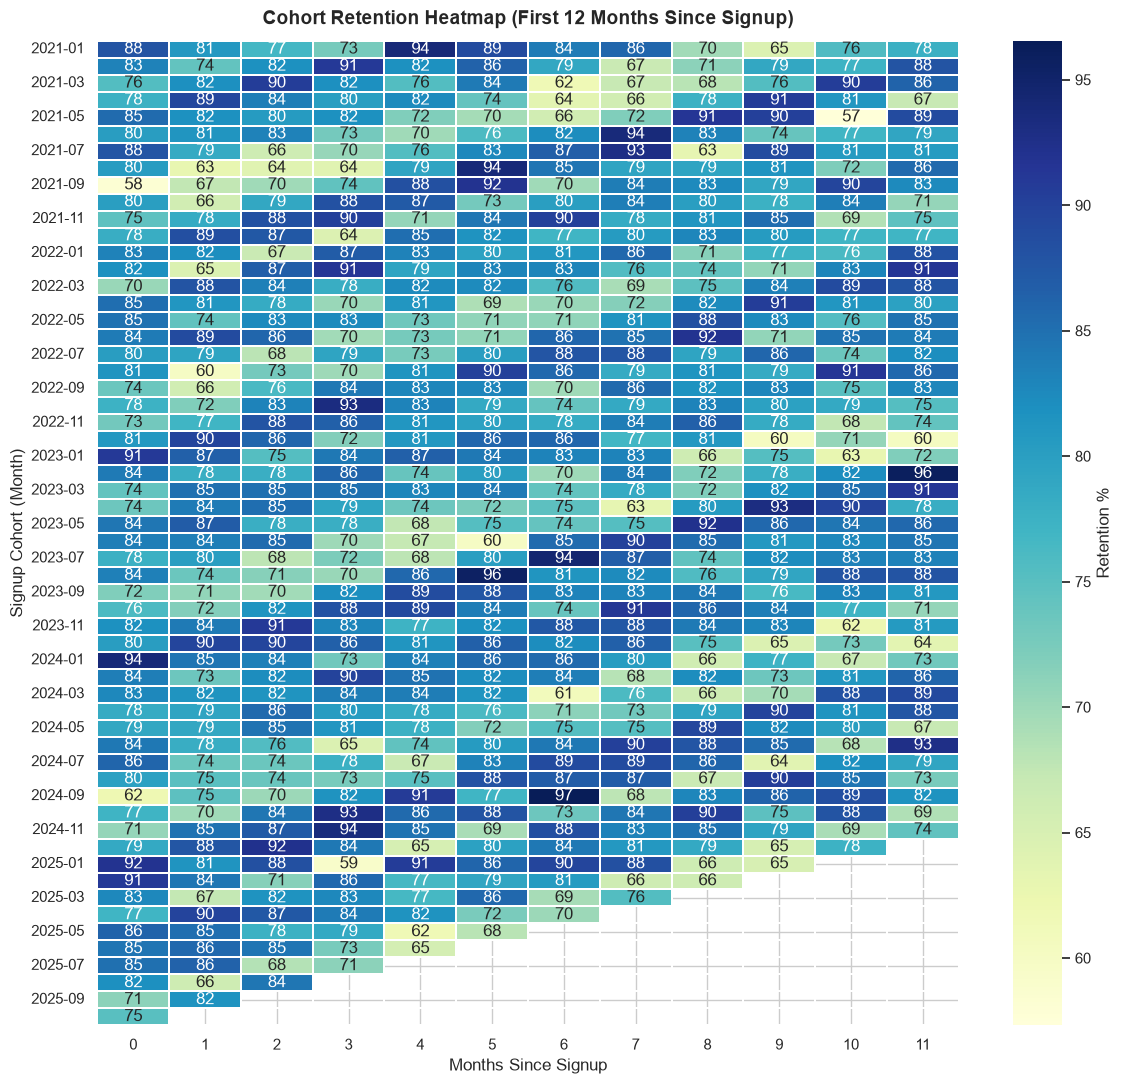

In [ ]:
cohort_pivot = (cohort_retention[cohort_retention["month_number"] <= 11]
                 .pivot(index="cohort_month", columns="month_number", values="retention_pct"))

fig, ax = plt.subplots(figsize=(12, 11))
sns.heatmap(cohort_pivot, annot=True, fmt=".0f", cmap="YlGnBu", ax=ax,
            cbar_kws={"label": "Retention %"}, linewidths=0.3)
ax.set_title("Cohort Retention Heatmap (First 12 Months Since Signup)", fontsize=14, fontweight="bold")
ax.set_xlabel("Months Since Signup")
ax.set_ylabel("Signup Cohort (Month)")
plt.tight_layout()
plt.savefig("chart5_cohort_retention_heatmap.png", dpi=150)
plt.show()

### Bonus charts

Two extra charts that directly support the business questions below (the task
requires 5+ charts; these are #6 and #7).

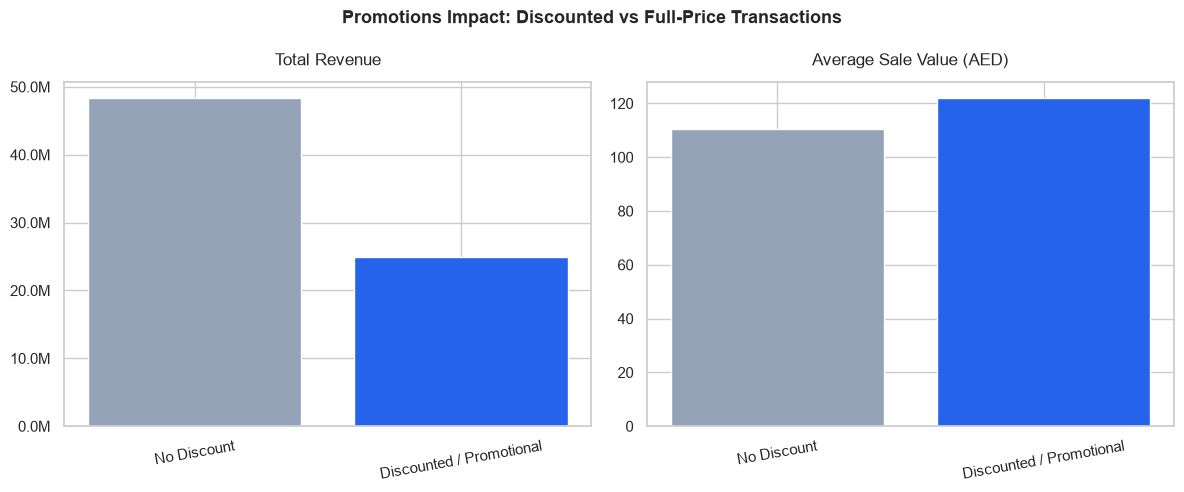

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(promo_comparison["promotion_status"], promo_comparison["total_revenue"],
            color=["#94a3b8", "#2563eb"])
axes[0].set_title("Total Revenue")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
axes[0].tick_params(axis="x", rotation=10)

axes[1].bar(promo_comparison["promotion_status"], promo_comparison["average_sale_value"],
            color=["#94a3b8", "#2563eb"])
axes[1].set_title("Average Sale Value (AED)")
axes[1].tick_params(axis="x", rotation=10)

fig.suptitle("Promotions Impact: Discounted vs Full-Price Transactions", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("chart6_promotions_impact.png", dpi=150)
plt.show()

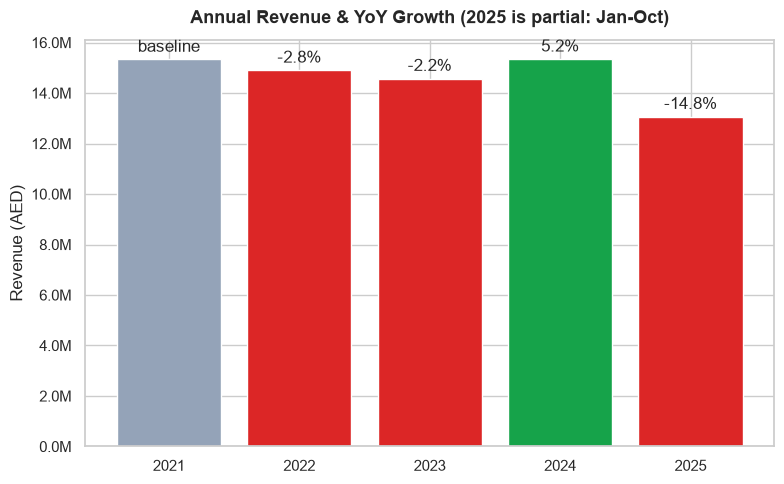

In [ ]:
colors = ["#94a3b8" if pd.isna(v) else ("#16a34a" if v >= 0 else "#dc2626")
          for v in revenue_growth["yoy_growth_pct"]]
labels = [f"{v:.1f}%" if pd.notna(v) else "baseline" for v in revenue_growth["yoy_growth_pct"]]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(revenue_growth["sales_year"].astype(str), revenue_growth["total_revenue"], color=colors)
ax.bar_label(bars, labels=labels, padding=3)
ax.set_title("Annual Revenue & YoY Growth (2025 is partial: Jan-Oct)", fontsize=13, fontweight="bold")
ax.set_ylabel("Revenue (AED)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
plt.tight_layout()
plt.savefig("chart7_yoy_revenue_growth.png", dpi=150)
plt.show()

## 4. Business Questions

In [ ]:
# ---- Q1: Which category and region gives the highest revenue? ----
top_category = category_revenue.sort_values("total_revenue", ascending=False).iloc[0]
top_region = revenue_by_city.index[0]
top_region_revenue = revenue_by_city.iloc[0]

# ---- Q2: How many customers are at risk of leaving? ----
at_risk = rfm_summary.loc[rfm_summary["customer_segment"] == "At Risk"].iloc[0]
lost = rfm_summary.loc[rfm_summary["customer_segment"] == "Lost"].iloc[0]
champions = rfm_summary.loc[rfm_summary["customer_segment"] == "Champions"].iloc[0]

# ---- Q3: Did promotions help increase sales? ----
no_discount = promo_comparison.loc[promo_comparison["promotion_status"] == "No Discount"].iloc[0]
discounted = promo_comparison.loc[promo_comparison["promotion_status"] == "Discounted / Promotional"].iloc[0]
aov_lift_pct = (discounted["average_sale_value"] / no_discount["average_sale_value"] - 1) * 100
promo_share_pct = discounted["number_of_sales"] / (discounted["number_of_sales"] + no_discount["number_of_sales"]) * 100

print("Q1:", f"{top_category['category']} is the top category (AED {top_category['total_revenue']:,.0f}); "
      f"{top_region} is the top region (AED {top_region_revenue:,.0f}).")
print("Q2:", f"{int(at_risk['customer_count']):,} customers ({at_risk['pct_of_customers']}%) are 'At Risk'; "
      f"a further {int(lost['customer_count']):,} ({lost['pct_of_customers']}%) are already 'Lost'.")
print("Q3:", f"Promotional transactions have a {aov_lift_pct:.1f}% higher average sale value "
      f"(AED {discounted['average_sale_value']:.2f} vs AED {no_discount['average_sale_value']:.2f}), "
      f"and make up {promo_share_pct:.0f}% of all transactions.")

Q1: Electronics is the top category (AED 40,794,794); Dubai is the top region (AED 41,044,846).
Q2: 1,081 customers (21.62%) are 'At Risk'; a further 920 (18.4%) are already 'Lost'.
Q3: Promotional transactions have a 10.4% higher average sale value (AED 121.88 vs AED 110.42), and make up 32% of all transactions.


## 5. Export `summary_metrics.csv`
A flat, Power-BI-friendly metric table for the next mini-project.

In [ ]:
summary_metrics = pd.DataFrame([
    {"metric": "total_revenue_2021_to_oct2025", "value": round(monthly_revenue["monthly_revenue"].sum(), 2)},
    {"metric": "total_sales_no_discount", "value": int(no_discount["number_of_sales"])},
    {"metric": "total_sales_discounted", "value": int(discounted["number_of_sales"])},
    {"metric": "top_category", "value": top_category["category"]},
    {"metric": "top_category_revenue", "value": round(top_category["total_revenue"], 2)},
    {"metric": "top_region", "value": top_region},
    {"metric": "top_region_revenue", "value": round(top_region_revenue, 2)},
    {"metric": "customers_at_risk", "value": int(at_risk["customer_count"])},
    {"metric": "customers_lost", "value": int(lost["customer_count"])},
    {"metric": "customers_champions", "value": int(champions["customer_count"])},
    {"metric": "champions_pct_of_revenue", "value": champions["pct_of_revenue"]},
    {"metric": "aov_no_discount", "value": round(no_discount["average_sale_value"], 2)},
    {"metric": "aov_discounted", "value": round(discounted["average_sale_value"], 2)},
    {"metric": "aov_lift_pct_discounted_vs_full_price", "value": round(aov_lift_pct, 2)},
    {"metric": "promo_share_of_transactions_pct", "value": round(promo_share_pct, 2)},
    {"metric": "yoy_growth_2024_pct", "value": revenue_growth.loc[revenue_growth["sales_year"] == 2024, "yoy_growth_pct"].iloc[0]},
    {"metric": "yoy_growth_2025_partial_pct", "value": revenue_growth.loc[revenue_growth["sales_year"] == 2025, "yoy_growth_pct"].iloc[0]},
    {"metric": "repeat_purchase_rate_pct", "value": repeat_purchase_rate["repeat_purchase_rate_pct"].iloc[0]},
])

summary_metrics.to_csv("summary_metrics.csv", index=False)
print("Saved summary_metrics.csv")
summary_metrics

Saved summary_metrics.csv


,metric,value
0,total_revenue_2021_to_oct2025,73214931.3
1,total_sales_no_discount,437475
2,total_sales_discounted,204368
3,top_category,Electronics
4,top_category_revenue,40794793.88
5,top_region,Dubai
6,top_region_revenue,41044846.36
7,customers_at_risk,1081
8,customers_lost,920
9,customers_champions,539


## 6. Executive Summary PDF
One page, written for a non-technical business audience, answering the 3 required
business questions plus headline metrics and recommendations.

In [ ]:
sections = [
    ("Business Question 1: Which category and region gives the highest revenue?",
     f"{top_category['category']} is the leading product category with AED {top_category['total_revenue']:,.0f} "
     f"in revenue. {top_region} is the leading region with AED {top_region_revenue:,.0f} in revenue -- "
     f"more than double the next closest region."),
    ("Business Question 2: How many customers are at risk of leaving?",
     f"{int(at_risk['customer_count']):,} customers ({at_risk['pct_of_customers']}% of the base) fall into the "
     f"'At Risk' RFM segment, and a further {int(lost['customer_count']):,} ({lost['pct_of_customers']}%) are "
     f"already 'Lost'. Combined, close to 40% of the customer base needs a retention push, even though "
     f"they still represent a meaningful share of historical revenue."),
    ("Business Question 3: Did promotions help increase sales?",
     f"Yes, on a per-transaction basis. Promotional transactions carry a {aov_lift_pct:.1f}% higher average "
     f"sale value (AED {discounted['average_sale_value']:.2f}) than full-price transactions "
     f"(AED {no_discount['average_sale_value']:.2f}), even though they represent a minority "
     f"({promo_share_pct:.0f}%) of total transactions."),
]

key_metrics = [
    f"Total revenue (Jan 2021 - Oct 2025): AED {monthly_revenue['monthly_revenue'].sum():,.0f}",
    f"2024 full-year growth: {revenue_growth.loc[revenue_growth['sales_year'] == 2024, 'yoy_growth_pct'].iloc[0]:.1f}% YoY",
    f"Repeat purchase rate: {repeat_purchase_rate['repeat_purchase_rate_pct'].iloc[0]:.1f}%",
    f"Champions segment: {int(champions['customer_count']):,} customers driving {champions['pct_of_revenue']}% of revenue",
]

recommendations = [
    "Protect Dubai Electronics as the core revenue engine, while testing category-mix promotions in "
    "Abu Dhabi and Sharjah to close the regional gap.",
    "Launch a win-back campaign targeted at the 'At Risk' / 'Lost' customers before they fully churn "
    "-- they still represent a meaningful share of historical revenue.",
    "Expand promotions selectively: they lift average order value, so pair them with frequently "
    "co-purchased products to raise basket size further.",
]

fig = plt.figure(figsize=(8.27, 11.69))  # A4 portrait
fig.patch.set_facecolor("white")
y = 0.96

fig.text(0.07, y, "Retail Intelligence \u2014 Executive Summary", fontsize=19, fontweight="bold")
y -= 0.020
fig.text(0.07, y, "20-Day Data Analytics Bootcamp | Project 1 | Day 4", fontsize=10, color="gray")
y -= 0.038

for heading, text in sections:
    fig.text(0.07, y, heading, fontsize=11.5, fontweight="bold", color="#1e3a8a")
    y -= 0.026
    for line in textwrap.wrap(text, 100):
        fig.text(0.07, y, line, fontsize=9.5)
        y -= 0.019
    y -= 0.014

fig.text(0.07, y, "Key Metrics", fontsize=11.5, fontweight="bold", color="#1e3a8a")
y -= 0.026
for m in key_metrics:
    fig.text(0.085, y, f"\u2022 {m}", fontsize=9.5)
    y -= 0.019
y -= 0.014

fig.text(0.07, y, "Recommendations", fontsize=11.5, fontweight="bold", color="#1e3a8a")
y -= 0.026
for i, r in enumerate(recommendations, 1):
    lines = textwrap.wrap(f"{i}. {r}", 98)
    for j, line in enumerate(lines):
        fig.text(0.085 if j else 0.07, y, line, fontsize=9.5)
        y -= 0.019
    y -= 0.010

fig.text(0.07, 0.025,
         "Source: day2_aggregations.sql & day3_advanced_analytics.sql outputs, analyzed in retail_eda.ipynb",
         fontsize=7, color="gray")

with PdfPages("executive_summary.pdf") as pdf:
    pdf.savefig(fig)
plt.show()
print("Saved executive_summary.pdf")

<Figure size 827x1169 with 0 Axes>

Saved executive_summary.pdf


## 7. Next Step
`summary_metrics.csv` feeds directly into **Mini-Project 2**, which builds a Power BI
dashboard on top of these KPIs.